<a href="https://colab.research.google.com/github/topbased/testrepo/blob/main/New_plant_diseases_datset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Agriculture & Smart Farming - Computer Vision for Crop Disease Detection**

## **Executive Problem Statement**

## Global agriculture faces massive challenges as plant diseases and pests threaten food security and crop yields, with diseases contributing to massive yield losses annually. Traditional manual monitoring of crop health relies on farmers visually inspecting fields; this process is labor-intensive, prone to human error, and often catches outbreaks too late. Waiting too long to take action leads to devastating crop loss or the indiscriminate, environmentally harmful overuse of chemical pesticides.The objective of this project is to develop a deep learning-based image classifier utilizing Computer Vision. The model must analyze images of plant leaves to detect early signs of disease, enabling timely, targeted interventions and supporting precision agriculture objectives.


# **Week 1: Image Acquisition, EDA, and Preprocessing**


## **Importing the Libraries**

In [1]:
import pandas as ps
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

## **Importing the Dataset**


In [21]:
!kaggle datasets -d download vipoooool/new-plant-diseases-dataset

You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


In [22]:
!ls /content

data  new-plant-diseases-dataset.zip  sample_data


In [23]:
!unzip -q -o new-plant-diseases-dataset.zip -d /content/data

In [24]:
import os

for root, dirs, files in os.walk("/content/data"):
    print(root)

/content/data
/content/data/test
/content/data/test/test
/content/data/New Plant Diseases Dataset(Augmented)
/content/data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)
/content/data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
/content/data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/Tomato___Bacterial_spot
/content/data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/Corn_(maize)___Common_rust_
/content/data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/Peach___Bacterial_spot
/content/data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/Grape___Esca_(Black_Measles)
/content/data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/Cherry_(including_sour)___Powdery_mildew
/content/data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(A

In [25]:
data_dir = "/content/data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"

In [26]:
import os
print(os.listdir(data_dir)[:5])

['Tomato___Bacterial_spot', 'Corn_(maize)___Common_rust_', 'Peach___Bacterial_spot', 'Grape___Esca_(Black_Measles)', 'Cherry_(including_sour)___Powdery_mildew']


## **EDA**

## **CONFIRMING CLASSES**

In [28]:
import os

classes = os.listdir(data_dir)
print("Number of classes:", len(classes))
print("Sample classes:", classes[:5])

Number of classes: 38
Sample classes: ['Tomato___Bacterial_spot', 'Corn_(maize)___Common_rust_', 'Peach___Bacterial_spot', 'Grape___Esca_(Black_Measles)', 'Cherry_(including_sour)___Powdery_mildew']


## **CLASS DISTRIBUTION**

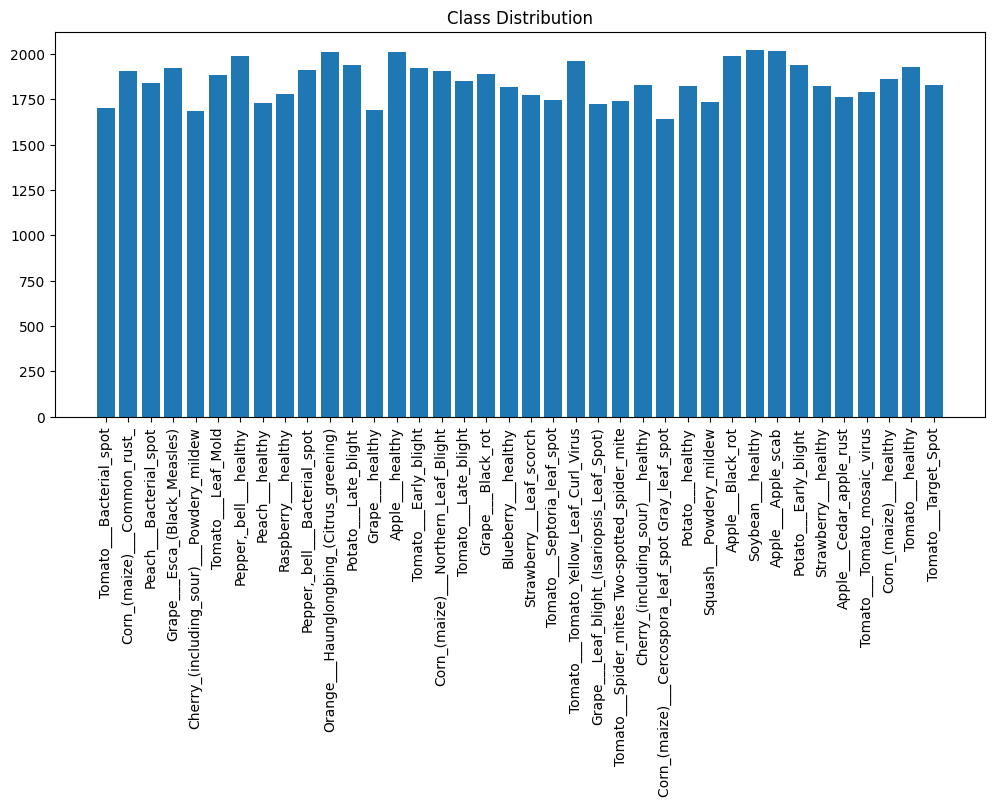

In [29]:
import matplotlib.pyplot as plt

class_counts = {cls: len(os.listdir(os.path.join(data_dir, cls))) for cls in classes}

plt.figure(figsize=(12,5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=90)
plt.title("Class Distribution")
plt.show()

## **The class distribution is fairly balanced, with most classes having a similar number of images. There is no significant class imbalance, which means the dataset is well-suited for training a robust and unbiased model.**

## **SAMPLE IMAGE**

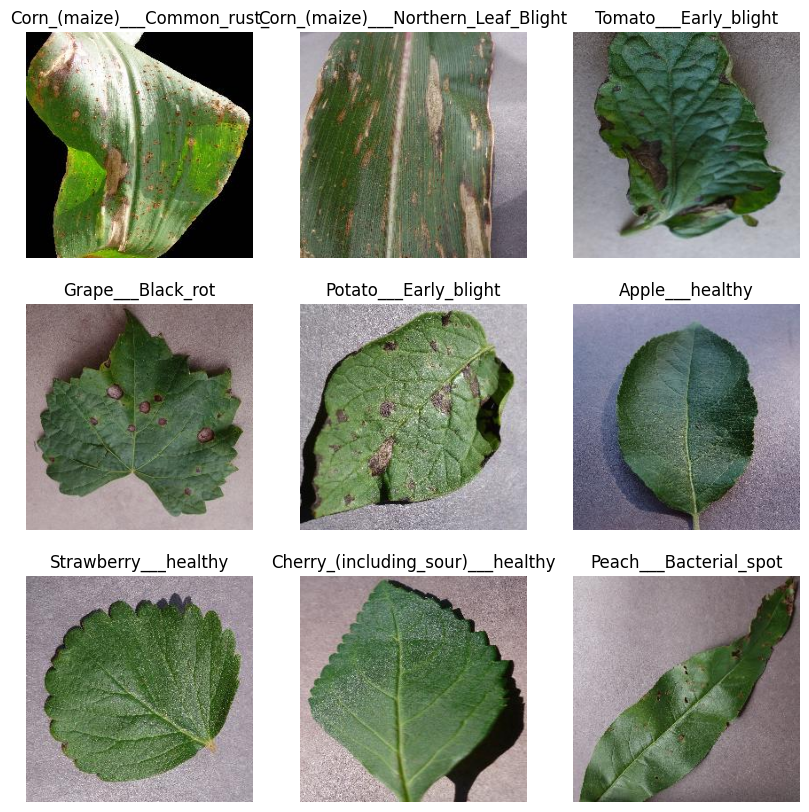

In [30]:
import cv2
import random

plt.figure(figsize=(10,10))

for i in range(9):
    cls = random.choice(classes)
    img_path = os.path.join(data_dir, cls, random.choice(os.listdir(os.path.join(data_dir, cls))))

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()

In [32]:
import numpy as np

print("Shape:", img.shape)
print("Min pixel:", np.min(img))
print("Max pixel:", np.max(img))

Shape: (256, 256, 3)
Min pixel: 0
Max pixel: 232


## **TRAIN/TEST/VAL SPLIT**

In [34]:
import shutil
import random

base_dir = "/content/processed_data"

train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")

for d in [train_dir, val_dir, test_dir]:
    os.makedirs(d, exist_ok=True)

for cls in classes:
    cls_path = os.path.join(data_dir, cls)
    images = os.listdir(cls_path)
    random.shuffle(images)

    total = len(images)
    train_split = int(0.7 * total)
    val_split = int(0.9 * total)

    splits = {
        train_dir: images[:train_split],
        val_dir: images[train_split:val_split],
        test_dir: images[val_split:]
    }

    for split_dir, split_imgs in splits.items():
        cls_folder = os.path.join(split_dir, cls)
        os.makedirs(cls_folder, exist_ok=True)

        for img in split_imgs:
            shutil.copyfile(os.path.join(cls_path, img),
                            os.path.join(cls_folder, img))



## **PREPROCESSING + AUGMENTATION**

In [35]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

## **DATA PIPELINE**

In [36]:
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

val_data = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_data = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

Found 63993 images belonging to 38 classes.
Found 25406 images belonging to 38 classes.
Found 13362 images belonging to 38 classes.


## **VERIFYING OUTPUT**

(32, 224, 224, 3)
(32, 38)


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

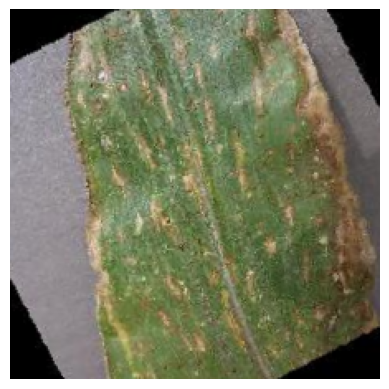

In [37]:
images, labels = next(train_data)

print(images.shape)
print(labels.shape)

plt.imshow(images[0])
plt.axis("off")

# **Week 2: Custom CNN Architecture and Baseline Training**


## **IMPORT THE LIBRARIES**

In [38]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

## **BUILDING CUSTOM CNN MODEL**

In [39]:
model = Sequential([

    # Conv Block 1
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    # Conv Block 2
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    # Conv Block 3
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    # Flatten
    Flatten(),

    # Fully Connected Layers
    Dense(128, activation='relu'),
    Dropout(0.5),   # Prevent overfitting

    Dense(train_data.num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## **COMPILING THE MODEL**

In [40]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,173,862 (42.62 MB)

 Trainable params: 11,173,862 (42.62 MB)

 Non-trainable params: 0 (0.00 B)

## **EARLY STOPPING**

In [41]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

## **TRAIN THE MODEL**

In [44]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=3,
    steps_per_epoch=20,
    validation_steps=10
)

Epoch 1/3
20/20 ━━━━━━━━━━━━━━━━━━━━ 88s 4s/step - accuracy: 0.7016 - loss: 0.9181 - val_accuracy: 0.8313 - val_loss: 0.4898
Epoch 2/3
20/20 ━━━━━━━━━━━━━━━━━━━━ 142s 7s/step - accuracy: 0.6953 - loss: 0.9774 - val_accuracy: 0.7875 - val_loss: 0.6257
Epoch 3/3
20/20 ━━━━━━━━━━━━━━━━━━━━ 143s 7s/step - accuracy: 0.7078 - loss: 0.8939 - val_accuracy: 0.8406 - val_loss: 0.5475


## **PLOT TRAINING VS VALIDATION**

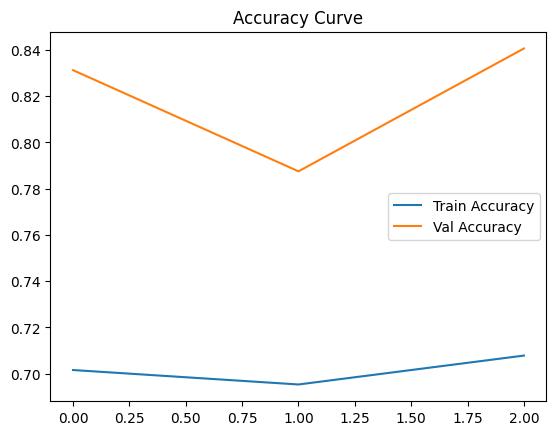

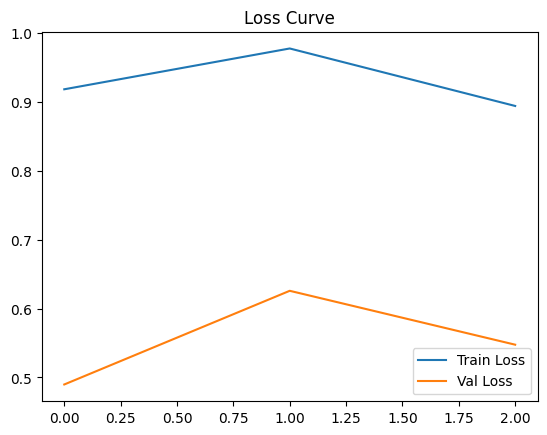

In [45]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()

## **The model shows stable learning, with validation accuracy remaining higher than training accuracy and loss decreasing over epochs.**

## **TEST EVALUATION**

In [46]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

418/418 ━━━━━━━━━━━━━━━━━━━━ 438s 1s/step - accuracy: 0.8269 - loss: 0.5528
Test Accuracy: 0.826897144317627


## **The model achieved a test accuracy of approximately 82.7%, indicating good performance on unseen data.This shows the model generalizes well and is effective for plant disease classification.**